# Preprocessing + Gold Standard - PHEME Dataset

In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

PROCESSED_PATH = '../../data/processed/'
GOLD_PATH = '../../data/gold_standard/'
FIGURES_PATH = '../../results/figures/'
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(GOLD_PATH, exist_ok=True)

## 1. Load Data

In [2]:
df = pd.read_csv('../../data/raw/PHEME-rumourdetection.csv')
df['label'] = df['is_rumor'].map({0.0: 'not_rumour', 1.0: 'rumour'})
df['topic'] = df['topic'].fillna('unknown')

# Drop rows with no label
df = df.dropna(subset=['label'])
print(f'Loaded: {len(df):,} rows')
print(df['label'].value_counts())

Loaded: 62,443 rows
label
not_rumour    48619
rumour        13824
Name: count, dtype: int64


## 2. Clean Text

In [3]:
def clean_tweet(text, max_chars=350):
    text = str(text)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'^RT\s*[:]?\s*', '', text, flags=re.IGNORECASE)
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'\"\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text[:max_chars]

df['cleaned_tweet'] = df['text'].apply(clean_tweet)
df['word_count'] = df['cleaned_tweet'].str.split().str.len()

print(f'Before filter: {len(df):,}')
df = df[df['word_count'] >= 5].drop_duplicates(subset='cleaned_tweet')
print(f'After filter + dedup: {len(df):,}')
print(df['label'].value_counts())

Before filter: 62,443
After filter + dedup: 49,804
label
not_rumour    38917
rumour        10887
Name: count, dtype: int64


In [4]:
cols = ['text', 'cleaned_tweet', 'label', 'topic', 'user.handle', 'word_count']
cols = [c for c in cols if c in df.columns]
df[cols].to_csv(f'{PROCESSED_PATH}pheme_clean.csv', index=False)
print(f'Saved: pheme_clean.csv ({len(df):,} rows)')

Saved: pheme_clean.csv (49,804 rows)


## 3. Create Gold Standard

In [5]:
rumour = df[df['label'] == 'rumour']
not_rumour = df[df['label'] == 'not_rumour'].sample(min(2000, (df['label'] == 'not_rumour').sum()), random_state=42)

gold = pd.concat([rumour, not_rumour], ignore_index=True)
gold = gold.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Gold Standard: {len(gold):,}')
print(gold['label'].value_counts())

train, temp = train_test_split(gold, test_size=0.30, stratify=gold['label'], random_state=42)
val, test = train_test_split(temp, test_size=0.50, stratify=temp['label'], random_state=42)
print(f'\nTrain: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')

Gold Standard: 12,887
label
rumour        10887
not_rumour     2000
Name: count, dtype: int64

Train: 9,020 | Val: 1,933 | Test: 1,934


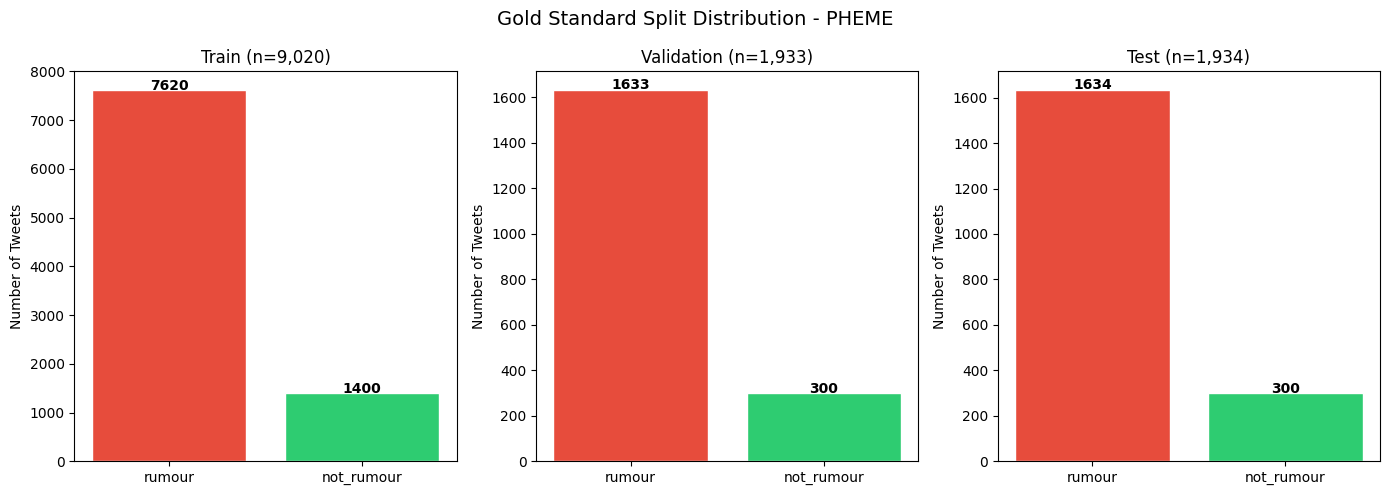

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, split_df, title in [(axes[0], train, 'Train'), (axes[1], val, 'Validation'), (axes[2], test, 'Test')]:
    counts = split_df['label'].value_counts()
    ax.bar(counts.index, counts.values,
           color=['#2ecc71' if x == 'not_rumour' else '#e74c3c' for x in counts.index],
           edgecolor='white')
    ax.set_title(f'{title} (n={len(split_df):,})', fontsize=12)
    ax.set_ylabel('Number of Tweets')
    for bar, val_ in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val_), ha='center', fontweight='bold')

plt.suptitle('Gold Standard Split Distribution - PHEME', fontsize=14)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}pheme_06_gold_standard_splits.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
gold.to_csv(f'{GOLD_PATH}pheme_gold_standard.csv', index=False)
train.to_csv(f'{GOLD_PATH}pheme_train.csv', index=False)
val.to_csv(f'{GOLD_PATH}pheme_val.csv', index=False)
test.to_csv(f'{GOLD_PATH}pheme_test.csv', index=False)

print('Saved:')
for name, df_ in [('gold_standard', gold), ('train', train), ('val', val), ('test', test)]:
    print(f'  pheme_{name}.csv ({len(df_):,} rows)')

Saved:
  pheme_gold_standard.csv (12,887 rows)
  pheme_train.csv (9,020 rows)
  pheme_val.csv (1,933 rows)
  pheme_test.csv (1,934 rows)


## 4. Sample Examples

In [8]:
print('Rumour samples:')
print('-'*60)
for _, row in test[test['label'] == 'rumour'].head(3).iterrows():
    print(f'Topic:    {row["topic"]}')
    print(f'Original: {str(row["text"])[:150]}')
    print(f'Cleaned:  {str(row["cleaned_tweet"])[:150]}')
    print()

print('Not rumour samples:')
print('-'*60)
for _, row in test[test['label'] == 'not_rumour'].head(3).iterrows():
    print(f'Topic:    {row["topic"]}')
    print(f'Original: {str(row["text"])[:150]}')
    print(f'Cleaned:  {str(row["cleaned_tweet"])[:150]}')
    print()

Rumour samples:
------------------------------------------------------------
Topic:    ferguson
Original: @ReignOfApril @QuadCityPat when he was questioned, they would have arrested him.
Cleaned:  when he was questioned, they would have arrested him.

Topic:    unknown
Original: @Ironyisfunny8 @econseptiles @greenhousenyt agree . He died a hero !!
Cleaned:  agree . He died a hero !!

Topic:    unknown
Original: @nadadictator @BBCBreaking @janeikelboom I know far more than you. Even if I stop talking as you would like, it won't alter the truth.
Cleaned:  I know far more than you. Even if I stop talking as you would like, it won't alter the truth.

Not rumour samples:
------------------------------------------------------------
Topic:    charliehebdo
Original: @kellybeane @CNN @fhollande you believe everything that u are told, don't you?
Cleaned:  you believe everything that u are told, don't you?

Topic:    unknown
Original: @cR_zStro rr if only it were true
Cleaned:  rr if only it were